In [ ]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
import random
import torch
#from squidpy.

from pathlib import Path

In [2]:
def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



set_full_reproducibility(42)

In [4]:
from joblib import load, dump

## Load Data

In [ ]:
adata=sc.read_h5ad('data/melton_jimenez_25/cosmx_pancreas_s1.h5ad')

## Load model and eval

In [24]:
import InterScale as interscale
from InterScale.tl import prepare_geome_dataset
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.config import load_config
from InterScale.tl import remove_zero_expression_cells

import argparse
import scanpy as sc

In [ ]:
cfg_path = 'config_files/melton_jimenez_25/InterScale_Cosmx_Nrec_globalPCA.yaml'
model_type = 'GlobalModel'
cfg = load_config(cfg_path)
print(cfg)
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata = remove_zero_expression_cells(adata)

dataset:
  batch_size: 32
  description: 
  group_label: condition
  h5ad_data: data/cosmx/adata_cosmx_IS.h5ad
  layer_key: log1p_norm
  name: cosmxnrecGPCA
  num_classes: -1
  num_features: -1
  pct_mask_nodes: 0.3
  prediction_level: node
  prediction_obs: None
  prediction_task: regression
  sample_key: ['sliding_window_assignment']
  segmentation_robustness: [0.2, 0.5]
  spatial_neigbors_kwargs:
    coord_type: generic
    library_key: sample
    n_neighs: 6
    radius: 200
  split_key: split
  stratify_group: None
  test_size: 0.1
  train_size: 0.7
  val_size: 0.2
model:
  decoder:
    dropout_decoder: 0.1
    dual_decoder: False
    hidden_dims: [256, 128]
    type: linear
  global_component:
    latent_obsm_key: X_cellcharter
    name: self-attn-transformer
    parameters:
      activation_func: relu
      dim_feedforward: 256
      dropout_global: 0.1
      long_range_attention: False
      max_seq_len: 1436
      n_heads: 4
      num_layers: 2
      type_gex_embedding: PCA
  l

In [26]:
interscale.model.GlobalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label)


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.4.0.post1.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│  n_group_label   │   2   │
│  n_sample_key_0  │  138  │
│       n_x        │  979  │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ group_label  │ adata.obs['_scvi_group_label']  │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                         sample_key_0 State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sliding_window_assignment'] │ 1_window_0  │          0          │
│                                        │ 2_window_0  │          1          │
│                                        │ 3_window_0  │          2          │
│                                        │ 4_window_0  │          3          │
│                                        │ 6_window_0  │          4          │
│                                        │ 7_window_0  │          5          │
│                                        │ 8_window_0  │          6          │
│                                        │ 9_window_0  │          7          │
│                                        │ 10_window_0 │          8          │
│                                        │ 11_window_0 │          9          │
│                                        │ 12_window_0 │         10          │
│                                        │ 13_window_0 │         11          │
│                                        │ 14_window_0 │         12          │
│                                        │ 15_window_0 │         13          │
│                                        │ 16_window_0 │         14          │
│                                        │ 17_window_0 │         15          │
│                                        │ 18_window_0 │         16          │
│                                        │ 19_window_0 │         17          │
│                                        │ 20_window_0 │         18          │
│                                        │ 21_window_0 │         19          │
│                                        │ 22_window_0 │         20          │
│                                        │ 23_window_0 │         21          │
│                                        │ 24_window_0 │         22          │
│                                        │ 1_window_1  │         23          │
│                                        │ 2_window_1  │         24          │
│                                        │ 3_window_1  │         25          │
│                                        │ 4_window_1  │         26          │
│                                        │ 6_window_1  │         27          │
│                                        │ 7_window_1  │         28          │
│                                        │ 8_window_1  │         29          │
│                                        │ 9_window_1  │         30          │
│                                        │ 10_window_1 │         31          │
│                                        │ 11_window_1 │         32          │
│                                        │ 12_window_1 │         33          │
│                                        │ 13_window_1 │         34          │
│                                        │ 14_window_1 │         35          │
│                                        │ 15_window_1 │         36          │
│                                        │ 16_window_1 │         37          │
│                                        │ 17_window_1 │         38          │
│                                        │ 18_window_1 │         39          │
│                                        │ 19_window_1 │         40          │
│                                        │ 20_window_1 │         41          │
│                                        │ 21_window_1 │         42          │
│                                        │ 22_window_1 │         43          │
│                                        │ 23_window_1 │         44          │
│                                        │ 24_window_1 │         45          │
│                                        │ 1_windo

                 group_label State Registry                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │     ND     │          0          │
│                        │    T1D     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

In [27]:
model=interscale.model.GlobalModel.load(adata=adata,cfg=cfg,dir_path='model',global_component=True)

Loading model from model/cosmxnrecGPCA_regr_node_44_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [28]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


## Interactions

In [ ]:
from InterScale.evaluation.net_streams import plot_all_spatial_net_streams
from InterScale.evaluation.net_streams import cluster_spatial_flows
from InterScale.evaluation.net_streams import plot_flow_clusters
from InterScale.evaluation.net_streams import map_clusters_to_cells

In [29]:
from InterScale.evaluation.net_streams import compute_hierarchical_net_flow, plot_global_directionality

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/evaluation/net_streams.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  colors = [color for cat, color in zip(adata.obs[cell_type_col].cat.categories, colors) if cat in cell_list]


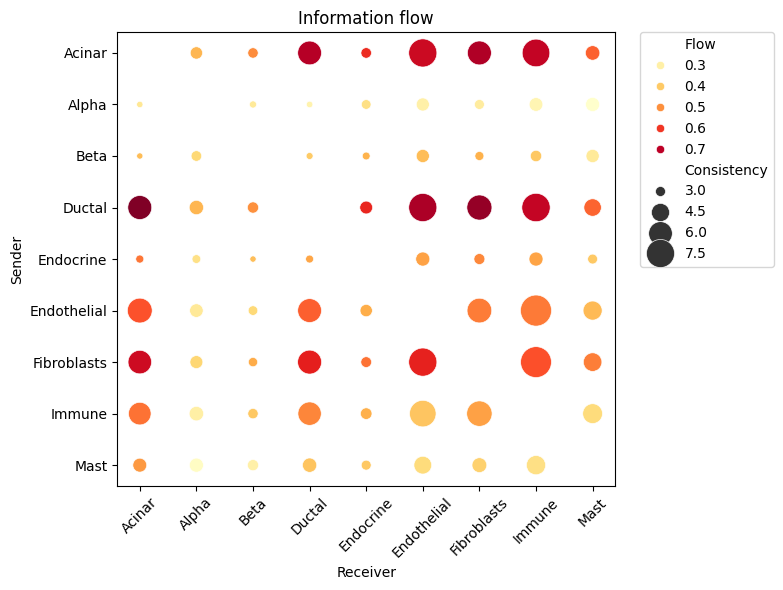

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/evaluation/net_streams.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  colors = [color for cat, color in zip(adata.obs[cell_type_col].cat.categories, colors) if cat in cell_list]
/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/evaluation/net_streams.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Setup spatial grid


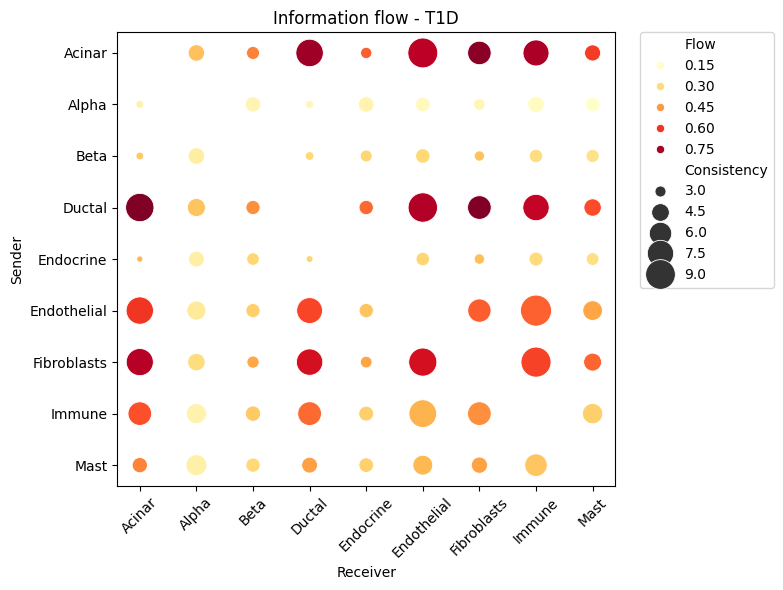

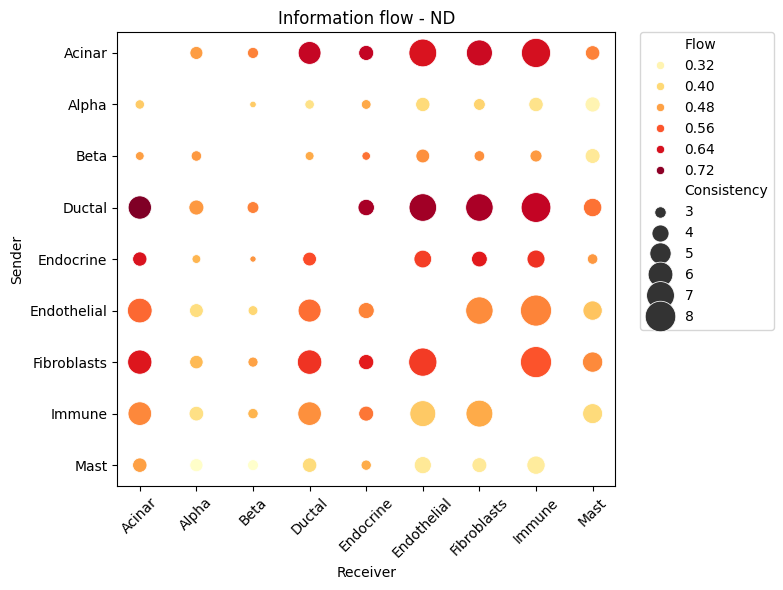

In [ ]:
#[result.obs['cell_type_coarse'].isin(['Immune','Beta','Alpha','Mast'])]

res=compute_hierarchical_net_flow(result,sample_key='sliding_window_assignment',cell_type_col='cell_type_coarse',compute_net=False)
plot_global_directionality(res['all_samples']['mean'], res['all_samples']['std'], only_positive=True, title="Information flow",figsize=(8, 6))

#[result.obs['cell_type_coarse'].isin(['Immune','Beta','Alpha','Mast'])]
res=compute_hierarchical_net_flow(result,sample_key='sliding_window_assignment',cell_type_col='cell_type_coarse',compute_net=False,condition_key='condition')
plot_global_directionality(res['T1D']['mean'], res['T1D']['std'], only_positive=True, title="Information flow - T1D",figsize=(8, 6))
plot_global_directionality(res['ND']['mean'], res['ND']['std'], only_positive=True, title="Information flow - ND",figsize=(8, 6))

In [ ]:
result.uns['cell_type_coarse_colors']=['#028e95','#f56d18','#ff0000','#25e907','#9c0101','#ea7b95','#f5d276',"#000000",'#0b559f']
result.obs['cell_type_coarse'].cat.categories

Index(['Acinar', 'Alpha', 'Beta', 'Ductal', 'Endocrine', 'Endothelial',
       'Fibroblasts', 'Immune', 'Mast'],
      dtype='object')

In [ ]:
cell_type_col='cell_type_coarse'
cell_list=['Alpha','Beta']
categories = list(result.obs[cell_type_col].cat.categories)
if cell_list is not None:
	categories = [cat for cat in categories if cat in cell_list]
if f'{cell_type_col}_colors' in result.uns:
	colors = list(result.uns[f'{cell_type_col}_colors'])
	if cell_list is not None:
		colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]
	color_map = dict(zip(categories, colors))

In [ ]:
color_map

colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]

{'Alpha': '#f56d18', 'Beta': '#ff0000'}

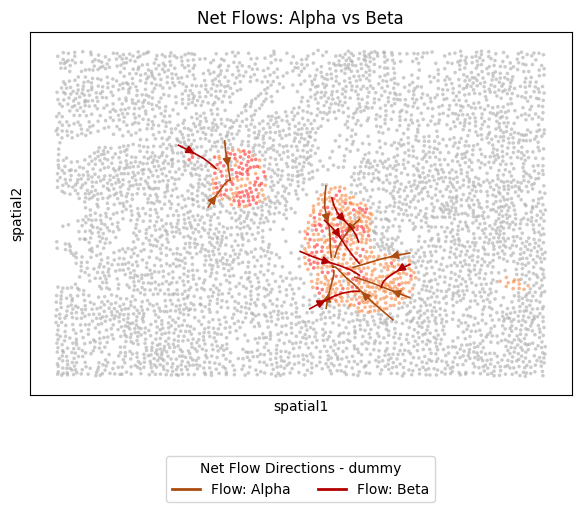

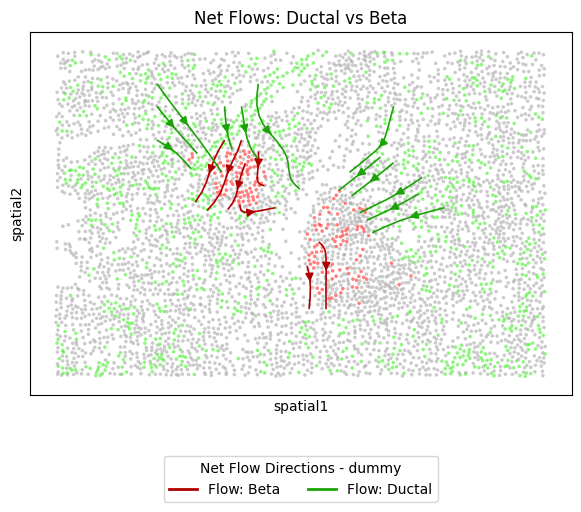

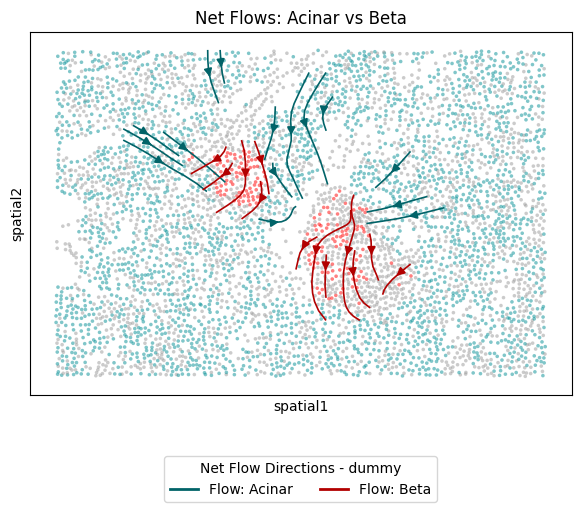

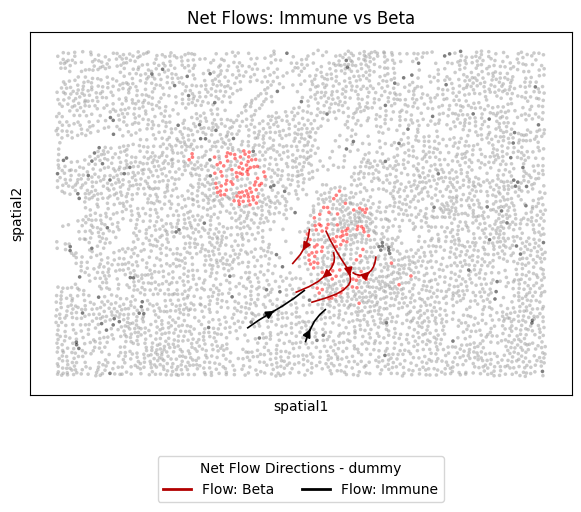

In [ ]:




from InterScale.evaluation.net_streams import plot_all_spatial_net_streams

for cell in ['Alpha','Ductal','Acinar','Immune']:

	fig, ax = plt.subplots(figsize=(7, 5))
	cell_list=[cell,'Beta']
	result.obs['dummy']=result.obs['cell_type_coarse'].apply(lambda x: x if x in cell_list else 'Other').astype('category')

	colors = list(result.uns[f'{cell_type_col}_colors'])
	colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]


	colors.append("#999999") # Aggiungiamo un colore grigio per 'Other'

	result.uns['dummy_colors']=colors

	plot_all_spatial_net_streams(result, fov_id='12',fov_key='fov',
								window_key='sliding_window_assignment',
								#additional_embeddings='dummy',
								k_dist=0.08,density=1,size=20,
								ax=ax,title=f'Net Flows: {cell_list[0]} vs {cell_list[1]}',
								inter_only=True,
		cell_type_col='dummy',alpha=0.5,cell_list=cell_list)


	plt.tight_layout()
